# 08 - Pipeline `clip-probe` (Optuna-tuned)

Frozen CLIP embeddings + trained MLP head. Cheapest to tune (embeddings cached once, each trial trains in seconds), so it gets the richest search space and the most trials.

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`. Artifacts -> `notebooks/artifacts/clip-probe/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "clip-probe"
ENCODER = ("ViT-B-32", "openai")
NORM = "clip"
WORKING_SIZE = 224
TUNE = True
N_TRIALS = 80
SEARCH_EPOCHS = 30
FINAL_EPOCHS = 60
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: clip-probe


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Data (cached CLIP embeddings)

In [3]:
from utils import embed
clip_model, clip_pre, clip_dev = embed.load_clip(ENCODER[0], ENCODER[1])
ms = pd.read_csv(SPLIT_PATH); ms = ms[ms["keep"]]
emb, lab = {}, {}
for split in ["train", "val", "test"]:
    sub = ms[ms["split_final"] == split].sort_values("cache_idx")
    lab[split] = (sub["label"].values == "fake").astype(np.float32)
    ep = AIR_DIR / f"clip_emb_{split}.npy"
    if ep.exists():
        emb[split] = np.load(ep)
    else:
        mm = np.load(AIR_DIR / "cache" / f"cache_{split}_256.npy", mmap_mode="r")
        emb[split] = embed.embed_uint8(clip_model, clip_dev, mm); del mm; np.save(ep, emb[split])
    print(f"{split}: {emb[split].shape}")
EMB_DIM = emb["train"].shape[1]

oodm = pd.read_csv(TINY_MANIFEST); oodm = oodm[oodm["keep"]].reset_index(drop=True)
oep = DATA_DIR / "tiny-genimage" / "clip_emb.npy"
emb_ood = np.load(oep) if oep.exists() else embed.embed_paths(oodm["filepath"].tolist(), clip_model, clip_pre, clip_dev, batch_size=128)
if not oep.exists():
    np.save(oep, emb_ood)
lab_ood = (oodm["label"].values == "fake").astype(np.float32)

def emb_loader(X, y, bs, shuffle):
    ds = torch.utils.data.TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=shuffle)
train_loader = emb_loader(emb["train"], lab["train"], 512, True)
val_loader = emb_loader(emb["val"], lab["val"], 1024, False)
test_loader = emb_loader(emb["test"], lab["test"], 1024, False)
print("embedding dim:", EMB_DIM)

C:\Users\user\AppData\Roaming\Python\Python312\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


train: (43127, 512)
val: (4792, 512)
test: (11963, 512)
embedding dim: 512


## 2 - Hyperparameter search (Optuna)

In [4]:
SEARCH_SPACE = {
    "hidden": {"type": "categorical", "choices": [128, 256, 512, 1024]},
    "n_layers": {"type": "int", "low": 1, "high": 3},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.6},
    "lr": {"type": "loguniform", "low": 3e-4, "high": 3e-3},
    "weight_decay": {"type": "loguniform", "low": 1e-5, "high": 1e-3},
    "label_smooth": {"type": "float", "low": 0.0, "high": 0.1},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"hidden": 256, "n_layers": 1, "p_drop": 0.3, "lr": 1e-3, "weight_decay": 1e-4, "label_smooth": 0.05, "loss": "bce"}

def objective(trial):
    p = {
        "hidden": trial.suggest_categorical("hidden", [128, 256, 512, 1024]),
        "n_layers": trial.suggest_int("n_layers", 1, 3),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.6),
        "lr": trial.suggest_float("lr", 3e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.1),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    gamma = trial.suggest_float("focal_gamma", 1.0, 3.0) if p["loss"] == "focal" else 2.0
    head = M.build_mlp_head(EMB_DIM, hidden=p["hidden"], n_layers=p["n_layers"], p_drop=p["p_drop"]).to(device)
    try:
        return TU.quick_train_eval(head, train_loader, val_loader, device, lr=p["lr"], weight_decay=p["weight_decay"],
                                   epochs=SEARCH_EPOCHS, trial=trial, loss_fn=TU.make_loss(p["loss"], gamma), label_smooth=p["label_smooth"])
    finally:
        TU.cleanup(head)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if TUNE:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))
else:
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print("TUNE off -> using", best)

  trial 00: COMPLETE value=0.9817


  trial 01: COMPLETE value=0.9837


  trial 02: COMPLETE value=0.9920


  trial 03: COMPLETE value=0.9865


  trial 04: COMPLETE value=0.9877


...

  trial 78: COMPLETE value=0.9938


  trial 79: PRUNED   value=0.9919


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])



BEST: {'hidden': 1024, 'n_layers': 3, 'p_drop': 0.5435849383457132, 'lr': 0.0012626052481662423, 'weight_decay': 1.552829956607584e-05, 'label_smooth': 0.0013897558179016695, 'loss': 'focal', 'focal_gamma': 2.1548718110403824} | val_auc 0.994


## 3 - Final train (best params)

In [5]:
model = M.build_mlp_head(EMB_DIM, hidden=best["hidden"], n_layers=best["n_layers"], p_drop=best["p_drop"]).to(device)
loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
spe = len(train_loader); scheduler = T.build_cosine_with_warmup(optimizer, total_steps=FINAL_EPOCHS * spe, warmup_steps=2 * spe)
stopper = T.EarlyStopper(mode="max", patience=10, min_delta=1e-4)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0; ckpt_path = dirs["models"] / "best.pt"
for epoch in range(FINAL_EPOCHS):
    tr = T.train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler, label_smooth=best["label_smooth"])
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]; T.save_checkpoint(ckpt_path, model, optimizer, epoch=epoch, best_metric=best_auc, extra={"history": history})
    if stop:
        print("early stopping at", epoch + 1); break
print("final best val auc:", round(best_auc, 4))

early stopping at 25
final best val auc: 0.9935


## 4 - Training curves

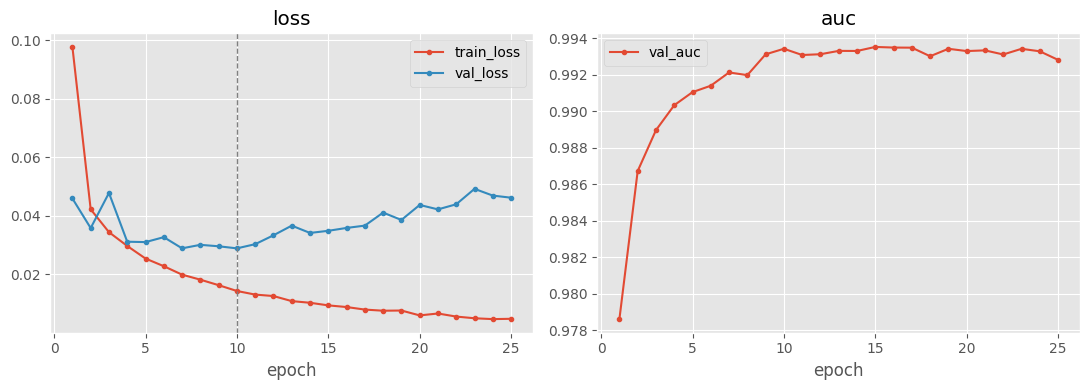

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - In-distribution evaluation

tuned threshold: 0.5625


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.959208,0.959207,0.961028,0.957169,0.993024,0.993196,0.918422,0.0318


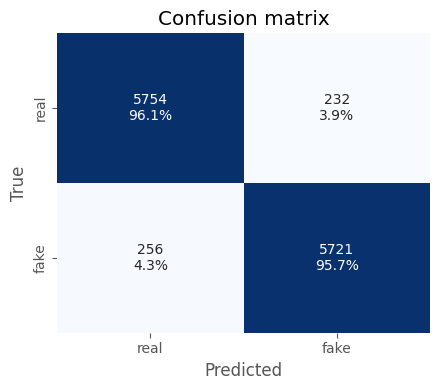

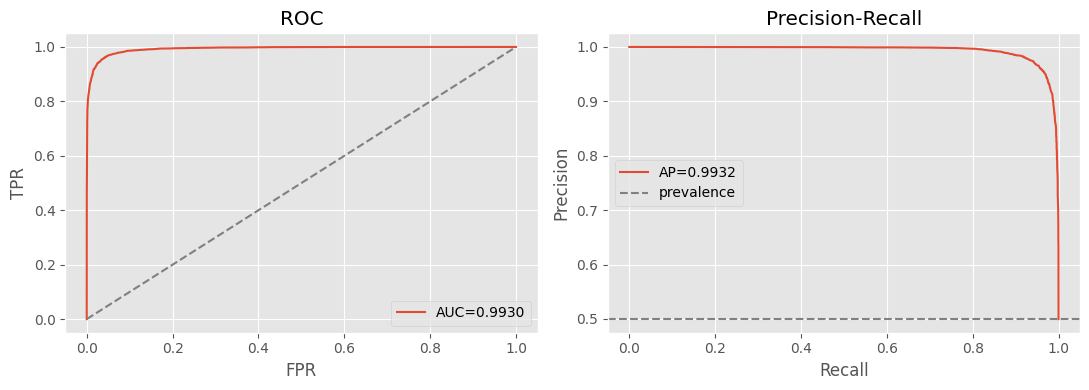

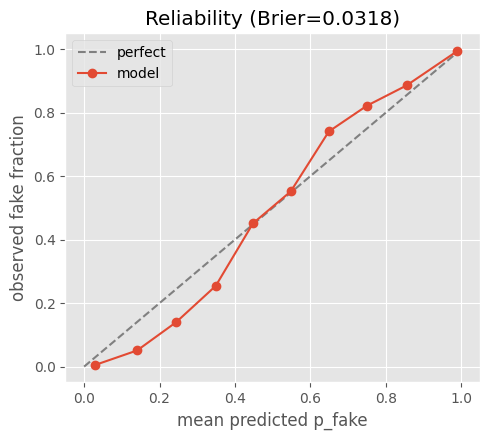

In [7]:
T.load_checkpoint(ckpt_path, model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold:", round(tuned["threshold"], 4)); display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

,generator,accuracy,n
0,adm,0.654000,5000
1,biggan,0.459200,5000
2,glide,0.543800,5000
3,midjourney,0.699340,4999
4,sdv5,0.632727,4999
5,vqdm,0.438600,5000
6,wukong,0.658000,5000


overall OOD accuracy: 0.5837  (in-dist 0.9592)


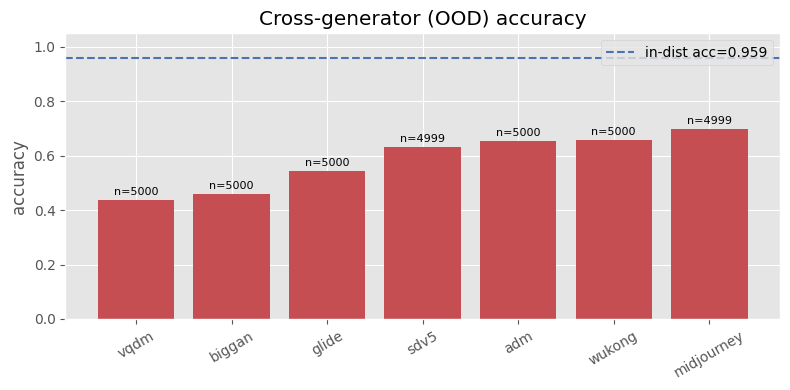

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader = emb_loader(emb_ood, lab_ood, 1024, False)
yo, po, _ = T.evaluate(model, ood_loader, device)
o2 = oodm.assign(p_fake=po, y_true=yo); o2["y_pred"] = (o2["p_fake"] >= 0.5).astype(int)
o2["generator"] = o2["source"].map(GEN_MAP).fillna(o2["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in o2.groupby("generator")])
overall_ood = float((o2["y_pred"] == o2["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (embedding t-SNE)

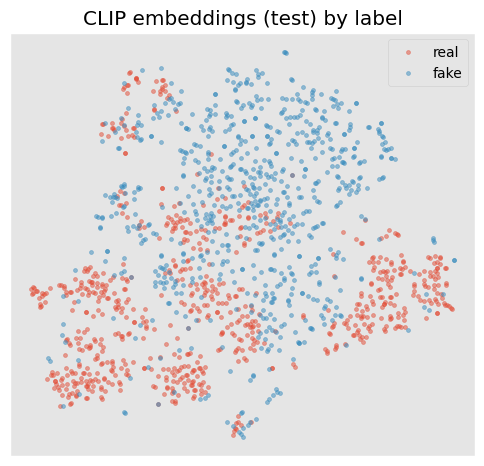

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
def tsne2d(X, seed=42):
    Xp = PCA(n_components=min(50, X.shape[1]), random_state=seed).fit_transform(StandardScaler().fit_transform(X))
    return TSNE(n_components=2, init="pca", perplexity=30, random_state=seed).fit_transform(Xp)
rng = np.random.RandomState(42); ti = rng.choice(len(emb["test"]), size=min(1500, len(emb["test"])), replace=False)
fig, ax = plt.subplots(figsize=(6, 5.5)); xy = tsne2d(emb["test"][ti]); labs = np.where(lab["test"][ti] > 0.5, "fake", "real")
for v in ["real", "fake"]:
    m = labs == v; ax.scatter(xy[m, 0], xy[m, 1], s=8, alpha=0.5, label=v)
ax.legend(); ax.set_title("CLIP embeddings (test) by label"); ax.set_xticks([]); ax.set_yticks([])
fig.savefig(dirs["figures"] / "tsne_embeddings.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "encoder": "/".join(ENCODER), "embedding_dim": int(EMB_DIM),
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'tsne_embeddings']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\clip-probe\metrics\metrics.json
